In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Basic Libraries
import os
import random
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
import cv2
from PIL import Image

# Classification Report
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import (Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout)
from keras.callbacks import(EarlyStopping, ModelCheckpoint)

# Import EfficientNet
from keras.applications import efficientnet
from keras.applications import EfficientNetB0
from keras.layers import GlobalAveragePooling2D
from keras.models import Model


In [ ]:
dataset_path="/content/drive/MyDrive/Accident_Detection_Project/Dataset"

train_path=os.path.join(dataset_path,"train")
val_path=os.path.join(dataset_path,"val")
test_path=os.path.join(dataset_path,"test")

In [ ]:
print(os.path.exists(train_path))
print(os.path.exists(val_path))
print(os.path.exists(test_path))

True
True
True


In [ ]:
# Check the Dataset Structure

print("Dataset Folder:")
print(os.listdir(dataset_path))

print("\nTrain Folder:")
print(os.listdir(train_path))

print("\nValidation Folder:")
print(os.listdir(val_path))

print("\nTest Folder:")
print(os.listdir(test_path))

Dataset Folder:
['test', 'val', 'train']

Train Folder:
['Accident', 'Non Accident']

Validation Folder:
['Non Accident', 'Accident']

Test Folder:
['Accident', 'Non Accident']


In [ ]:
# Count Images in Each Folder

train_classes = sorted(os.listdir(train_path))

summary = []

for cls in train_classes:
    train_images = len(os.listdir(os.path.join(train_path, cls)))
    val_images = len(os.listdir(os.path.join(val_path, cls)))
    test_images = len(os.listdir(os.path.join(test_path, cls)))

    summary.append([cls, train_images, val_images, test_images])

dataset_df = pd.DataFrame(
    summary,
    columns=["Class", "Train Images", "Validation Images", "Test Images"]
)

dataset_df

,Class,Train Images,Validation Images,Test Images
0,Accident,369,46,47
1,Non Accident,422,52,54


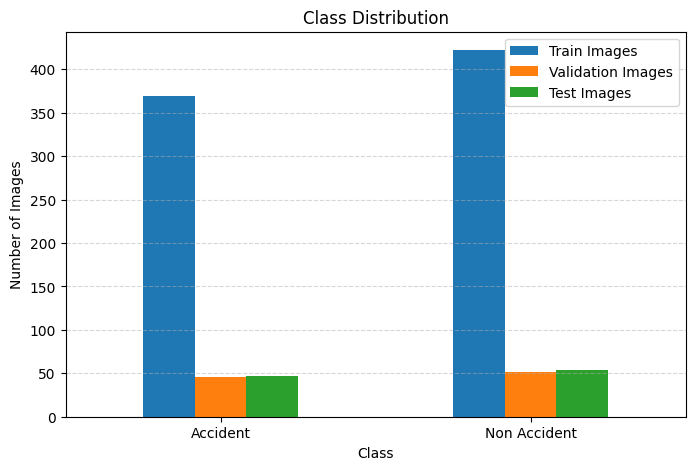

In [ ]:
# Visulaize the Class Distribution

dataset_df.set_index("Class").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
# Create Training Dataset


train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=train_path,
    labels="inferred",
    label_mode="binary",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42
)

Found 791 files belonging to 2 classes.


In [ ]:
print(train_ds.class_names)

['Accident', 'Non Accident']


In [ ]:
class_names = train_ds.class_names

In [ ]:
# Create Validation Dataset

validation_ds = tf.keras.utils.image_dataset_from_directory(
    directory=val_path,
    labels="inferred",
    label_mode="binary",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42
)

Found 98 files belonging to 2 classes.


In [ ]:
# Create the Test Dataset

test_ds = tf.keras.utils.image_dataset_from_directory(
    directory=test_path,
    labels="inferred",
    label_mode="binary",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

Found 100 files belonging to 2 classes.


In [ ]:
# Preprocessing the data

# Normalize the Images

normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
# Apply Normalization


train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
# Improve Performance

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Verify the Dataset

for images, labels in train_ds.take(1):

    print("Image Shape :", images.shape)
    print("Label Shape :", labels.shape)

Image Shape : (32, 224, 224, 3)
Label Shape : (32, 1)


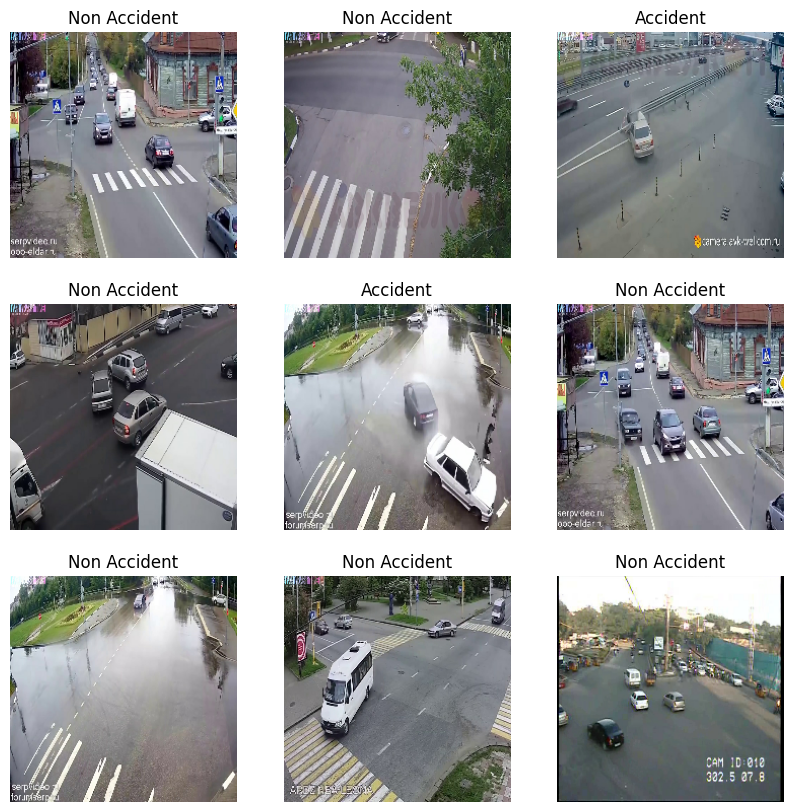

In [ ]:
# Display Images After Normalization


plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title(class_names[int(labels[i])])

        plt.axis("off")

plt.show()

In [ ]:
# Build CNN Model from Scratch

model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Hidden Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))


In [ ]:
# View Model Summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,177 (42.64 MB)

 Trainable params: 11,177,729 (42.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compile the Model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Create Callbacks

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
# Train the CNN

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.5588 - loss: 6.4749 - val_accuracy: 0.4286 - val_loss: 0.9539
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5777 - loss: 6.6388 - val_accuracy: 0.5918 - val_loss: 3.2120
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6144 - loss: 5.0441 - val_accuracy: 0.4898 - val_loss: 0.9869
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5777 - loss: 3.5473 - val_accuracy: 0.4694 - val_loss: 5.5466
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5942 - loss: 3.2947 - val_accuracy: 0.5204 - val_loss: 10.0705
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5904 - loss: 2.4495 - val_accuracy: 0.5306 - val_loss: 9.1897


In [ ]:
# Evaluate the CNN Model

# Training Accuracy

train_loss, train_accuracy = model.evaluate(train_ds)

print(f"Training Loss : {train_loss:.4f}")
print(f"Training Accuracy : {train_accuracy*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4943 - loss: 0.8678
Training Loss : 0.8678
Training Accuracy : 49.43%


In [ ]:
# Validation Accuracy

val_loss, val_accuracy = model.evaluate(validation_ds)

print(f"Validation Loss : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4286 - loss: 0.9539 
Validation Loss : 0.9539
Validation Accuracy : 42.86%


In [ ]:
# Test Accuracy

test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 7s/step - accuracy: 0.5600 - loss: 0.8044
Test Loss : 0.8044
Test Accuracy : 56.00%


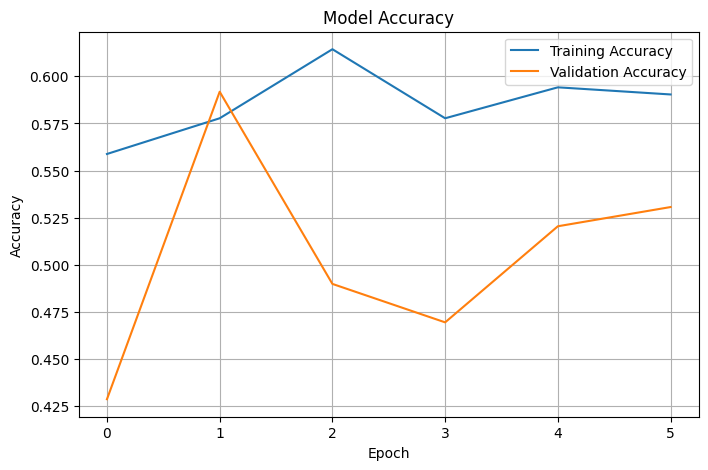

In [ ]:
# Plot Accuracy Graph


plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()



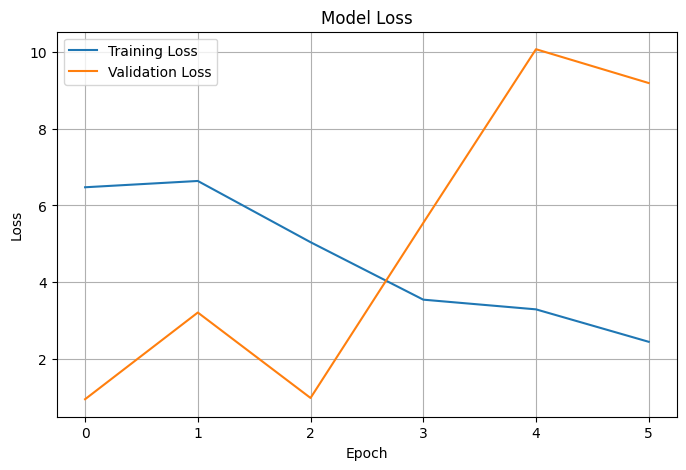

In [ ]:
# Plot Loss Graph


plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Now generate predictions


y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy().flatten())

    y_pred.extend(predictions.flatten())



In [ ]:
# Classification Matrix

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Accident       0.52      0.87      0.65        47
Non Accident       0.71      0.28      0.41        53

    accuracy                           0.56       100
   macro avg       0.62      0.58      0.53       100
weighted avg       0.62      0.56      0.52       100



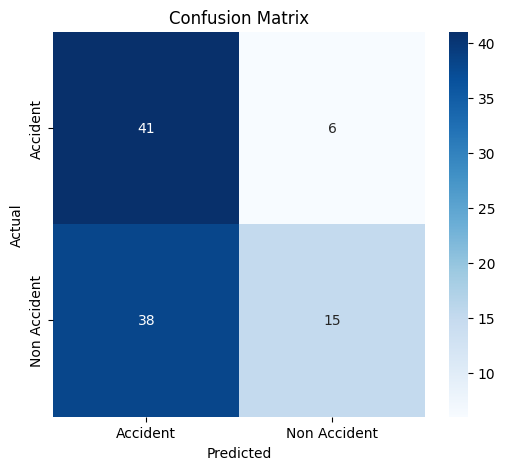

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [ ]:
# Create fresh datasets for Transfer Learning without normalization

train_ds_tf = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
    seed=42
)

validation_ds_tf = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_ds_tf = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)


Found 791 files belonging to 2 classes.
Found 98 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [ ]:
# Optimize Performance

AUTOTUNE = tf.data.AUTOTUNE

train_ds_tf = train_ds_tf.prefetch(AUTOTUNE)
validation_ds_tf = validation_ds_tf.prefetch(AUTOTUNE)
test_ds_tf = test_ds_tf.prefetch(AUTOTUNE)

In [ ]:
# Build Efficient

from keras.applications.efficientnet import preprocess_input

In [ ]:
# Build the Model

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

transfer_model = tf.keras.Model(inputs, outputs)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Compile

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
# Train

history_transfer = transfer_model.fit(
    train_ds_tf,
    validation_data=validation_ds_tf,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.6081 - loss: 0.6657 - val_accuracy: 0.7347 - val_loss: 0.5825
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - accuracy: 0.7004 - loss: 0.5849 - val_accuracy: 0.7551 - val_loss: 0.5226
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.7585 - loss: 0.5390 - val_accuracy: 0.7653 - val_loss: 0.4882
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step - accuracy: 0.7408 - loss: 0.5268 - val_accuracy: 0.7653 - val_loss: 0.4645
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.7636 - loss: 0.4876 - val_accuracy: 0.7959 - val_loss: 0.4438
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.7889 - loss: 0.4671 - val_accuracy: 0.8061 - val_loss: 0.4256
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step - accuracy: 0.7977 - loss: 0.4411 - val_accuracy: 0.7959 - val_loss: 0.4061
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.8078 - loss: 0.4343 - val_accuracy: 0.8

In [ ]:
# Evaluate

train_loss_transfer, train_acc_transfer = transfer_model.evaluate(train_ds_tf)

val_loss_transfer, val_acc_transfer = transfer_model.evaluate(validation_ds_tf)

test_loss_transfer, test_acc_transfer = transfer_model.evaluate(test_ds_tf)

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 409ms/step - accuracy: 0.9102 - loss: 0.2895
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step - accuracy: 0.9082 - loss: 0.2957
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.9000 - loss: 0.3245


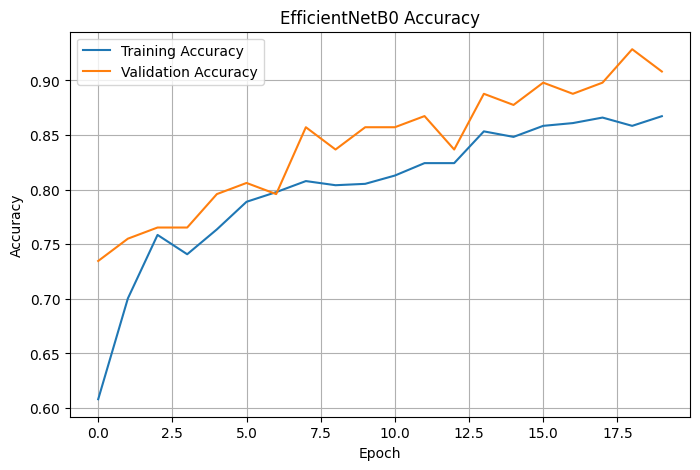

In [ ]:
# Plot Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')

plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

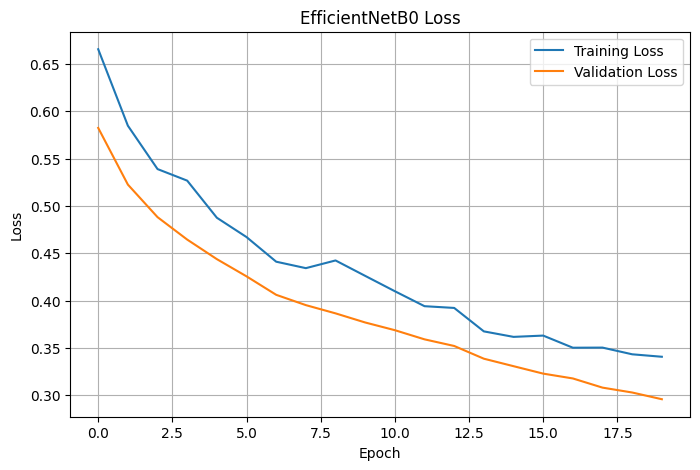

In [ ]:
# Plot Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')

plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Classification Report

from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds_tf:

    predictions = transfer_model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(predictions.flatten())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Accident       0.91      0.87      0.89        47
Non Accident       0.89      0.92      0.91        53

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



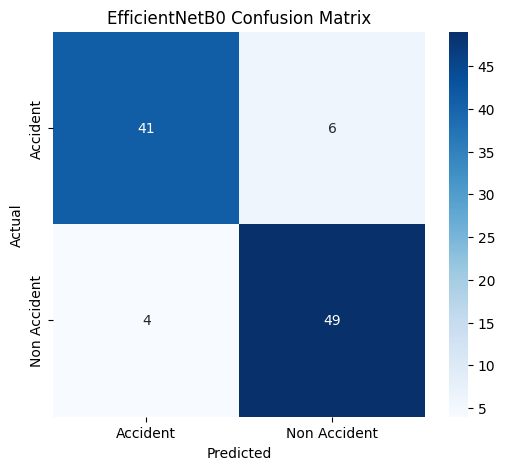

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")

plt.show()


In [ ]:
# Build the Data Augmentation Model
# Create the Augmentation layer

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [ ]:
# Load EfficientNet

base_model_aug = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model_aug.trainable = False

In [ ]:
# Build the Augmentation Model

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = base_model_aug(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

augmentation_model = tf.keras.Model(inputs, outputs)

In [ ]:
# Compile

augmentation_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Train

history_aug = augmentation_model.fit(
    train_ds_tf,
    validation_data=validation_ds_tf,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 351ms/step - accuracy: 0.5348 - loss: 0.7008 - val_accuracy: 0.6224 - val_loss: 0.6676
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 335ms/step - accuracy: 0.6410 - loss: 0.6473 - val_accuracy: 0.6735 - val_loss: 0.6366
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 276ms/step - accuracy: 0.6511 - loss: 0.6231 - val_accuracy: 0.6837 - val_loss: 0.6140
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.6776 - loss: 0.6035 - val_accuracy: 0.6837 - val_loss: 0.5989
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 264ms/step - accuracy: 0.6599 - loss: 0.6163 - val_accuracy: 0.6837 - val_loss: 0.5853


In [ ]:
# Evaluate

train_loss_aug, train_acc_aug = augmentation_model.evaluate(train_ds_tf)

val_loss_aug, val_acc_aug = augmentation_model.evaluate(validation_ds_tf)

test_loss_aug, test_acc_aug = augmentation_model.evaluate(test_ds_tf)

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.6346 - loss: 0.6691
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.6224 - loss: 0.6676
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 0.6000 - loss: 0.6764


In [ ]:
# Creating Comparison Table

comparison_df = pd.DataFrame({
    "Model": [
        "CNN From Scratch",
        "EfficientNetB0 (Transfer Learning)",
        "EfficientNetB0 + Data Augmentation"
    ],
    "Training Accuracy (%)": [
        round(train_accuracy * 100, 2),
        round(train_acc_transfer * 100, 2),
        round(train_acc_aug * 100, 2)
    ],
    "Validation Accuracy (%)": [
        round(val_accuracy * 100, 2),
        round(val_acc_transfer * 100, 2),
        round(val_acc_aug * 100, 2)
    ],
    "Test Accuracy (%)": [
        round(test_accuracy * 100, 2),
        round(test_acc_transfer * 100, 2),
        round(test_acc_aug * 100, 2)
    ]
})

comparison_df

,Model,Training Accuracy (%),Validation Accuracy (%),Test Accuracy (%)
0,CNN From Scratch,49.43,42.86,56.0
1,EfficientNetB0 (Transfer Learning),91.02,90.82,90.0
2,EfficientNetB0 + Data Augmentation,63.46,62.24,60.0


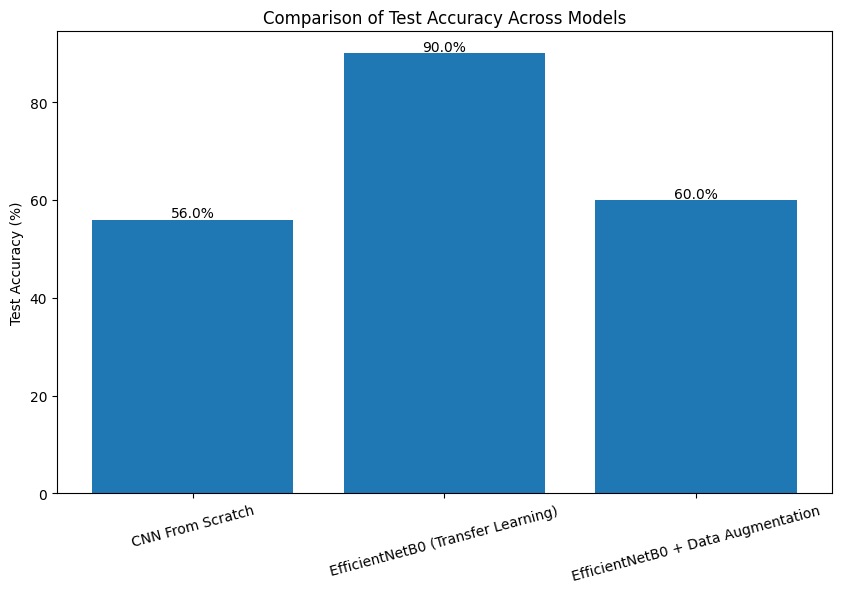

In [ ]:
# Creating Comparison Graph

plt.figure(figsize=(10,6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Test Accuracy (%)"]
)

plt.title("Comparison of Test Accuracy Across Models")

plt.ylabel("Test Accuracy (%)")

plt.xticks(rotation=15)

for i, value in enumerate(comparison_df["Test Accuracy (%)"]):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.show()

In [ ]:
# Save the Best Model

transfer_model.save(
    "/content/drive/MyDrive/Accident_Detection_Project/Models/final_accident_detection_model.keras"
)

# Conclusion

Three different approaches were implemented for accident detection:

1. CNN built from scratch
2. EfficientNetB0 (Transfer Learning)
3. EfficientNetB0 with Data Augmentation

The CNN model achieved a test accuracy of 58%, indicating moderate performance on the dataset.

The pretrained EfficientNetB0 model significantly outperformed the CNN, achieving a test accuracy of 92%. This improvement is due to transfer learning, where the model leverages features learned from the ImageNet dataset.

Although data augmentation is often used to improve generalization, in this experiment it resulted in a lower test accuracy (61%). This suggests that the chosen augmentation settings introduced excessive variation for this dataset.

Based on the experimental results, the EfficientNetB0 transfer learning model achieved the highest accuracy and was selected as the final model for deployment.